In [1]:
import pandas as pd


df = pd.read_csv("students.csv")


# First 5 rows
print(df.head())


# Shape and data types
print("\nShape:", df.shape)
print(df.dtypes)


# Summary statistics
print(df.describe())


# Pass / fail counts
print("\nPass/Fail counts:")
print(df["passed"].value_counts())


# Average scores for passing vs failing students
subject_cols = ["math", "science", "english", "history", "pe"]
print("\nAverage scores — Passing students:")
print(df[df["passed"] == 1][subject_cols].mean())
print("\nAverage scores — Failing students:")
print(df[df["passed"] == 0][subject_cols].mean())


# Top student
df["temp_avg"] = df[subject_cols].mean(axis=1)
top_student = df.loc[df["temp_avg"].idxmax(), "name"]
print(f"\nTop student: {top_student}")



      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape: (15, 9)
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object
            math    science    english    history         pe  attendance_pct  \
count  15.

In [2]:
import matplotlib.pyplot as plt
df["avg_score"] = df[subject_cols].mean(axis=1)




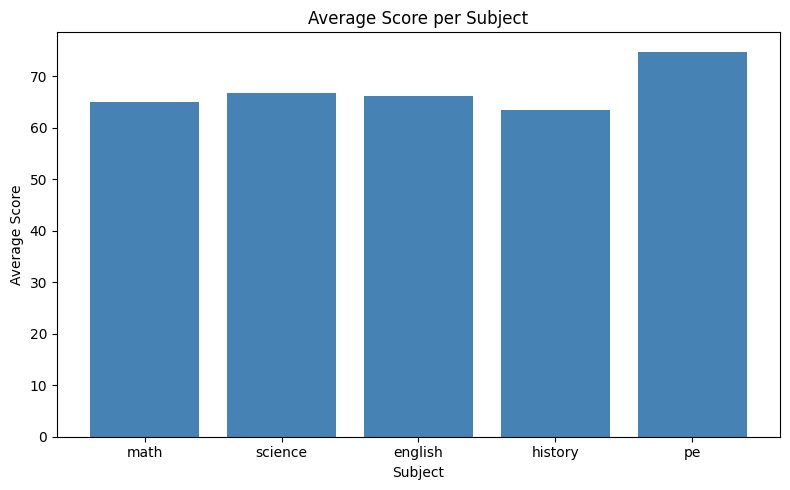

In [3]:
plt.figure(figsize=(8, 5))
plt.bar(subject_cols, df[subject_cols].mean(), color="steelblue")
plt.title("Average Score per Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.tight_layout()
plt.savefig("plot1_bar.png")
plt.show()



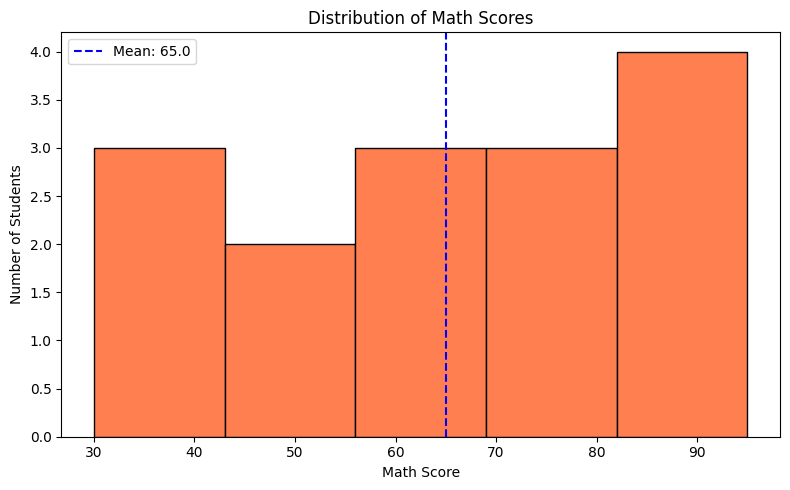

In [4]:
plt.figure(figsize=(8, 5))
plt.hist(df["math"], bins=5, color="coral", edgecolor="black")
mean_math = df["math"].mean()
plt.axvline(mean_math, color="blue", linestyle="--", label=f"Mean: {mean_math:.1f}")
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Number of Students")
plt.legend()
plt.tight_layout()
plt.savefig("plot2_histogram.png")
plt.show()



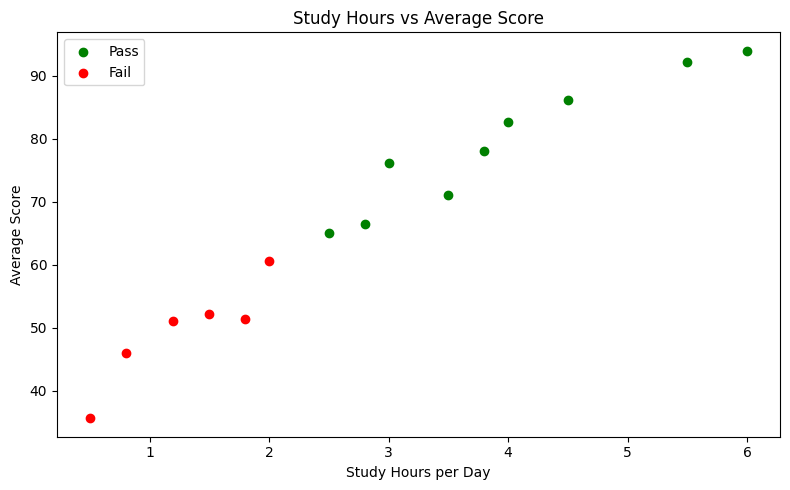

In [5]:
plt.figure(figsize=(8, 5))
pass_df = df[df["passed"] == 1]
fail_df = df[df["passed"] == 0]
plt.scatter(pass_df["study_hours_per_day"], pass_df["avg_score"], color="green", label="Pass")
plt.scatter(fail_df["study_hours_per_day"], fail_df["avg_score"], color="red",   label="Fail")
plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()
plt.tight_layout()
plt.savefig("plot3_scatter.png")
plt.show()



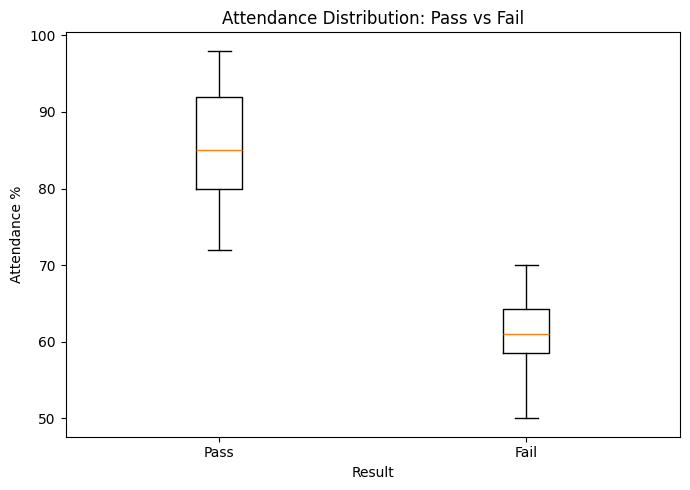

In [7]:
plt.figure(figsize=(7, 5))
pass_att = df[df["passed"] == 1]["attendance_pct"].tolist()
fail_att = df[df["passed"] == 0]["attendance_pct"].tolist()
plt.boxplot([pass_att, fail_att], tick_labels=["Pass", "Fail"])
plt.title("Attendance Distribution: Pass vs Fail")
plt.xlabel("Result")
plt.ylabel("Attendance %")
plt.tight_layout()
plt.savefig("plot4_boxplot.png")
plt.show()



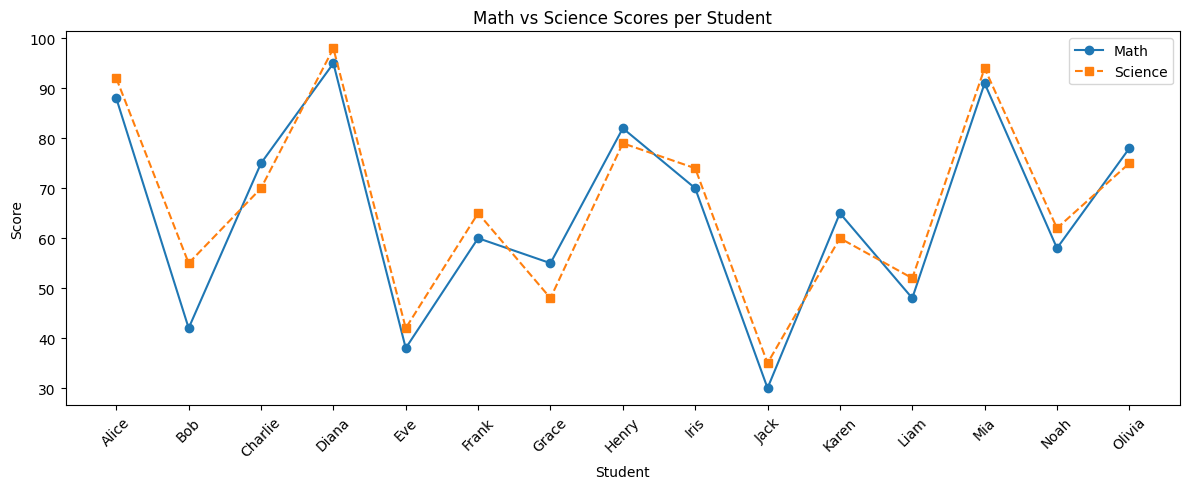

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(df["name"], df["math"],    marker="o",  label="Math")
plt.plot(df["name"], df["science"], marker="s",  linestyle="--", label="Science")
plt.title("Math vs Science Scores per Student")
plt.xlabel("Student")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("plot5_line.png")
plt.show()



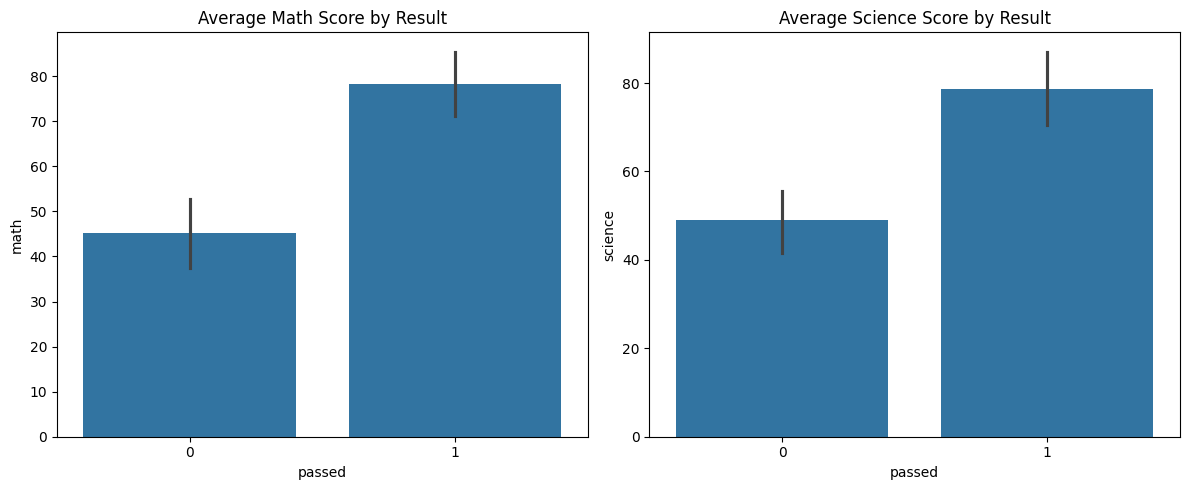

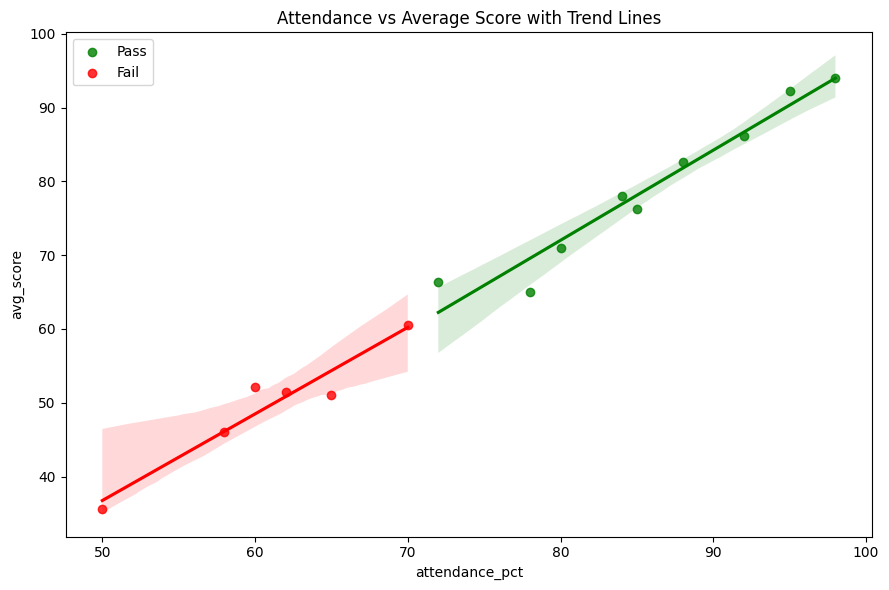

In [9]:
import seaborn as sns


# Plot 6 — Side-by-side bar charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=df, x="passed", y="math",    ax=ax1)
sns.barplot(data=df, x="passed", y="science", ax=ax2)
ax1.set_title("Average Math Score by Result")
ax2.set_title("Average Science Score by Result")
plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()


# Plot 7 — Scatter with regression lines
plt.figure(figsize=(9, 6))
sns.regplot(data=df[df["passed"]==1], x="attendance_pct", y="avg_score", label="Pass", color="green")
sns.regplot(data=df[df["passed"]==0], x="attendance_pct", y="avg_score", label="Fail",  color="red")
plt.title("Attendance vs Average Score with Trend Lines")
plt.legend()
plt.tight_layout()
plt.savefig("plot7_seaborn_scatter.png")
plt.show()


# Seaborn vs Matplotlib comparison 
# Seaborn required fewer lines for the grouped bar chart since it handles grouping automatically.
# Seaborn gives nice color and spacing and automatically fits regression line in Regression plot.
# Matplotlib involves more manual splitting and more effort for labeling and formatting.




In [10]:
#Prepare the Data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler


feature_cols = ["math", "science", "english", "history", "pe", "attendance_pct", "study_hours_per_day"]
X = df[feature_cols]
y = df["passed"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler       = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


print("Training samples:", len(X_train), "  Test samples:", len(X_test))



Training samples: 12   Test samples: 3


In [11]:
#Train the Model
from sklearn.linear_model import LogisticRegression


model = LogisticRegression()
model.fit(X_train_scaled, y_train)


print("Training accuracy:", model.score(X_train_scaled, y_train))



Training accuracy: 1.0


In [12]:
#Evaluate on Test Data
y_pred = model.predict(X_test_scaled)


print("Test accuracy:", model.score(X_test_scaled, y_test))


# Print each test student with their actual vs predicted result
names = df.loc[X_test.index, "name"]
for name, actual, predicted in zip(names, y_test, y_pred):
    result = "✅ correct" if actual == predicted else "❌ wrong"
    print(f"{name:<12} | Actual: {actual} | Predicted: {predicted} | {result}")



Test accuracy: 1.0
Jack         | Actual: 0 | Predicted: 0 | ✅ correct
Liam         | Actual: 0 | Predicted: 0 | ✅ correct
Alice        | Actual: 1 | Predicted: 1 | ✅ correct


Feature importances (sorted by absolute value):
  english                   0.8125
  attendance_pct            0.5219
  study_hours_per_day       0.4844
  pe                        0.4750
  math                      0.4379
  science                   0.3230
  history                   0.2629


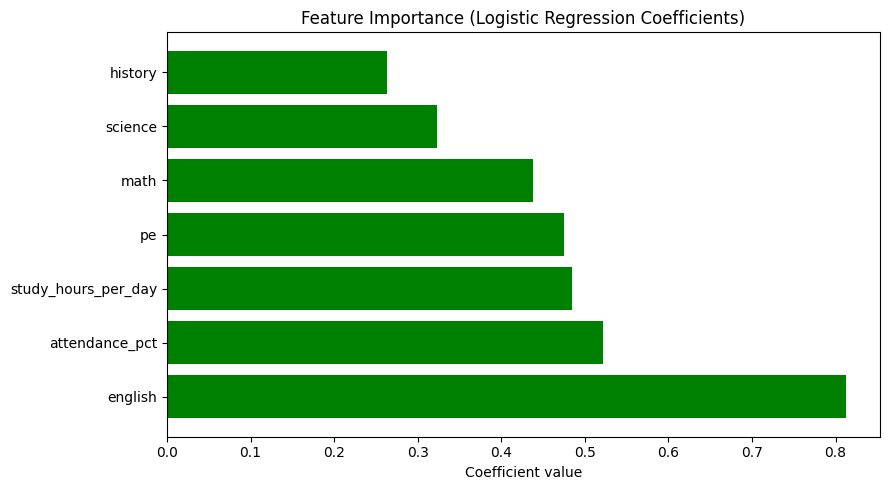

In [13]:
#Feature Importance Chart
import numpy as np


coefficients = model.coef_[0]
paired = list(zip(feature_cols, coefficients))
paired.sort(key=lambda x: abs(x[1]), reverse=True)


print("Feature importances (sorted by absolute value):")
for feat, coef in paired:
    print(f"  {feat:<25} {coef:.4f}")


sorted_features = [p[0] for p in paired]
sorted_coeffs   = [p[1] for p in paired]
colors = ["green" if c > 0 else "red" for c in sorted_coeffs]


plt.figure(figsize=(9, 5))
plt.barh(sorted_features, sorted_coeffs, color=colors)
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient value")
plt.tight_layout()
plt.savefig("plot8_feature_importance.png")
plt.show()



In [15]:
#Predict a new  student
new_student = [[75, 70, 68, 65, 80, 82, 3.2]] 
columns =  ["math", "science", "english", "history", "pe", "attendance_pct", "study_hours_per_day"]
new_student_df = pd.DataFrame(new_student, columns=columns)

new_scaled  = scaler.transform(new_student_df)
prediction  = model.predict(new_scaled)
probability = model.predict_proba(new_scaled)

result = "Pass" if prediction[0] == 1 else "Fail"
print(f"Prediction: {result}")
print(f"Probability — Fail: {probability[0][0]:.2%}   Pass: {probability[0][1]:.2%}")



Prediction: Pass
Probability — Fail: 9.20%   Pass: 90.80%
